In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
df = pd.read_csv("healthcare_dataset.csv")
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [3]:
import os
for root, dirs, files in os.walk("C:/Users/gayat/Desktop/Dataset"):
    for file in files:
        print(os.path.join(root, file))

In [4]:
print("Shape:", df.shape)
df.info()

Shape: (55500, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 non-null  object 
dtypes: float64(1), int64(2), object(12

In [5]:
print("Duplicate rows:", df.duplicated().sum())
df.describe()

Duplicate rows: 534


,Age,Billing Amount,Room Number
count,55500.000000,55500.000000,55500.000000
mean,51.539459,25539.316097,301.134829
std,19.602454,14211.454431,115.243069
min,13.000000,-2008.492140,101.000000
25%,35.000000,13241.224652,202.000000
50%,52.000000,25538.069376,302.000000
75%,68.000000,37820.508436,401.000000
max,89.000000,52764.276736,500.000000


In [6]:
# Remove duplicates
df = df.drop_duplicates()

# Check how many negative billing amounts exist
print("Negative billing rows:", (df['Billing Amount'] < 0).sum())

# Remove rows with negative billing (data entry errors)
df = df[df['Billing Amount'] >= 0]

print("New shape after cleaning:", df.shape)

Negative billing rows: 106
New shape after cleaning: (54860, 15)


In [7]:
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])
df['Discharge Date'] = pd.to_datetime(df['Discharge Date'])

# Create a new column: Length of Stay (in days)
df['Length of Stay'] = (df['Discharge Date'] - df['Date of Admission']).dt.days

df[['Date of Admission', 'Discharge Date', 'Length of Stay']].head()

,Date of Admission,Discharge Date,Length of Stay
0,2024-01-31,2024-02-02,2
1,2019-08-20,2019-08-26,6
2,2022-09-22,2022-10-07,15
3,2020-11-18,2020-12-18,30
4,2022-09-19,2022-10-09,20


In [8]:
#Question 1: What are the most common medical conditions?
df['Medical Condition'].value_counts()

Medical Condition
Arthritis       9207
Diabetes        9197
Hypertension    9131
Obesity         9127
Cancer          9121
Asthma          9077
Name: count, dtype: int64

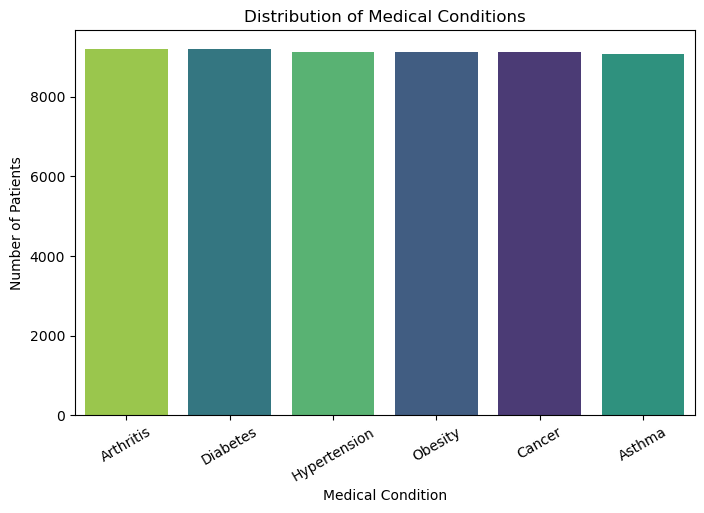

In [16]:
#Visualize medical condition distribution
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Medical Condition', hue='Medical Condition' , order=df['Medical Condition'].value_counts().index, palette='viridis',legend=False)
plt.title('Distribution of Medical Conditions')
plt.xlabel('Medical Condition')
plt.ylabel('Number of Patients')
plt.xticks(rotation=30)
plt.show()

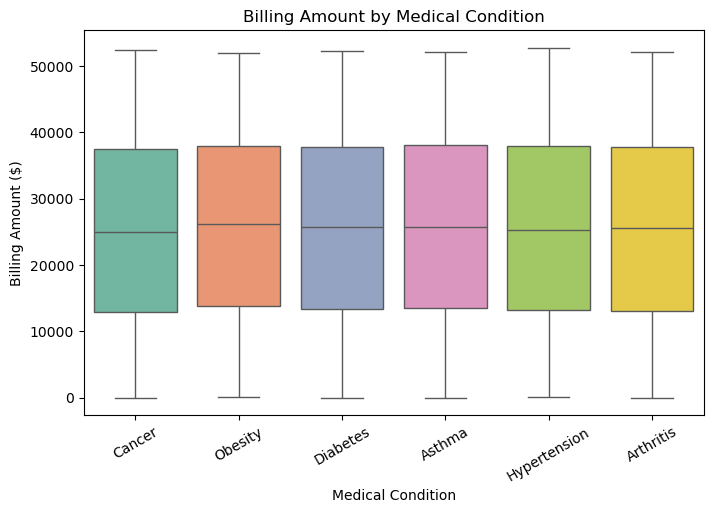

In [17]:
#Question 2: Does billing amount vary by medical condition?
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Medical Condition',hue='Medical Condition', y='Billing Amount', palette='Set2' , legend=False)
plt.title('Billing Amount by Medical Condition')
plt.xlabel('Medical Condition')
plt.ylabel('Billing Amount ($)')
plt.xticks(rotation=30)
plt.show()

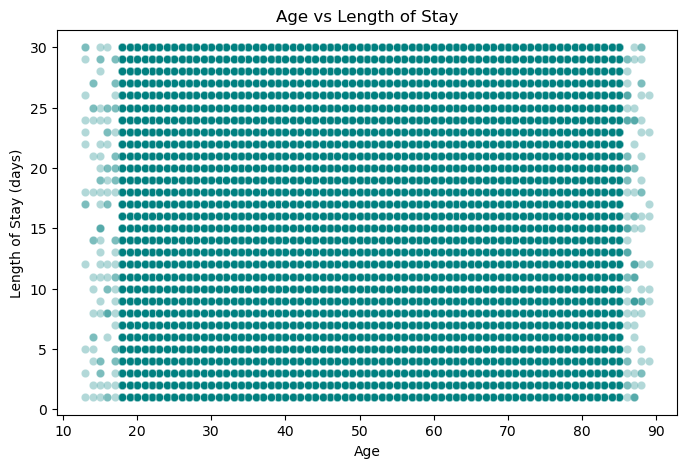

In [11]:
#Question 3: Does age relate to length of stay?
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Age', y='Length of Stay', alpha=0.3, color='teal')
plt.title('Age vs Length of Stay')
plt.xlabel('Age')
plt.ylabel('Length of Stay (days)')
plt.show()

<Figure size 800x500 with 0 Axes>

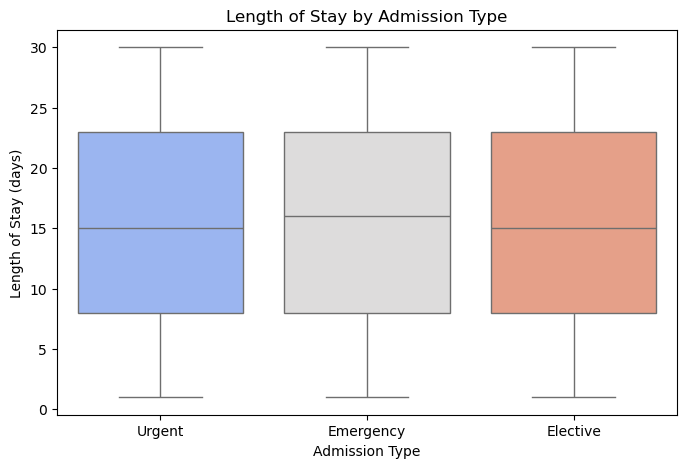

In [19]:
#Question 4: Which admission type is most common, and does it affect length of stay?

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Admission Type',hue='Admission Type', y='Length of Stay', palette='coolwarm',legend=False)
plt.title('Length of Stay by Admission Type')
plt.xlabel('Admission Type')
plt.ylabel('Length of Stay (days)')
plt.show()

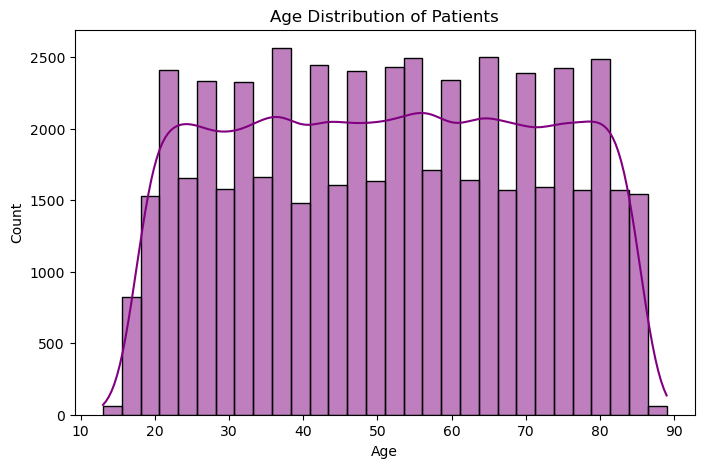

In [13]:
#age distribution chart
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=30, kde=True, color='purple')
plt.title('Age Distribution of Patients')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

## Key Insights

- Dataset contains 54,860 patient records after removing 534 duplicates and 106 rows with invalid (negative) billing amounts.
- Medical conditions are evenly distributed (~9,100 patients each across 6 conditions), suggesting synthetic/simulated data rather than real-world clinical records.
- Billing Amount shows no significant variation across medical conditions — median billing stays around $25,000–26,000 regardless of diagnosis.
- No correlation found between Age and Length of Stay.
- Admission Type (Urgent, Emergency, Elective) does not significantly affect Length of Stay.
- Age distribution is roughly uniform between 18–85, with sharp cutoffs at the dataset's age boundaries (13 and 89), further indicating synthetic data generation.

## Conclusion
This EDA demonstrates a complete exploratory workflow — data cleaning, feature engineering (Length of Stay), and multi-variable analysis using bar charts, boxplots, scatterplots, and histograms. While the dataset itself appears synthetically generated (shown by uniform distributions across all variables), the analysis process reflects real-world EDA practices used to validate data quality and identify (or rule out) relationships between variables.